# Dental Office Site Selection
### A Data-Driven Market Analysis · New Jersey · 20 Cities · 4 Counties
**Author:** Daniel Ona &nbsp;|&nbsp; **Date:** April 2026 &nbsp;|&nbsp; **Language:** R

---


In [27]:
knitr::opts_chunk$set(
  echo    = TRUE,
  message = FALSE,
  warning = FALSE,
  fig.width  = 10,
  fig.height = 6,
  dpi = 150,
  fig.align = "center"
)


In [28]:
# Auto-install any missing packages before loading
required_pkgs <- c("tidyverse", "scales", "knitr", "kableExtra", "ggrepel")
missing_pkgs  <- required_pkgs[!required_pkgs %in% rownames(installed.packages())]
if (length(missing_pkgs) > 0) {
  install.packages(missing_pkgs, repos = "https://cloud.r-project.org", quiet = TRUE)
}


In [29]:
library(tidyverse)
library(scales)
library(knitr)
library(kableExtra)
library(ggrepel)


# About This Project

This analysis was born from dinner-table conversations with two women who live and breathe the dental industry every day.

My **wife** is an experienced dental **office manager**. Through her, I have had a front-row seat to the operational realities of running a dental practice — from managing schedules and insurance billing to navigating patient flow and staff dynamics. She understands, better than anyone, what it takes to make a practice financially sustainable.

My **sister** is a dedicated dental **hygienist**. She has shared the clinical perspective with me: what patients need, what they expect, and which communities feel underserved when it comes to quality dental care.

Their combined knowledge planted a question: *what would the data say about where a new dental office should open?* This project is my attempt to answer that question rigorously — and it is my **first end-to-end data analysis project**.

Using publicly available demographic, economic, and dental market data for **20 New Jersey cities across 4 counties**, I built a weighted scoring framework to identify the most promising locations for a new private dental practice. The goal was not simply to find where need is greatest, but where that need intersects with the financial capacity and market conditions to sustain a profitable, growing practice.

> *This project is dedicated to my wife and sister, whose passion for the dental profession inspired every line of code and every chart in this report.*

---

# Executive Summary

After scoring all 20 markets across four weighted dimensions — market competition, household income, insurance coverage, and population underservice — two cities emerged as the strongest candidates for a new dental office:

| Rank | City | County | Opp. Score | Key Strength |
|:----:|------|--------|:----------:|--------------|
| 🥇 | **West Orange** | Essex | **61.9 / 100** | Affluent suburban market; 5,776 people per dentist |
| 🥈 | **Hoboken** | Hudson | **56.2 / 100** | Highest income; documented implant/ortho service gap |
| 3 | Rahway | Union | 55.3 / 100 | Least saturated market in Union County |
| 4 | Linden | Union | 43.7 / 100 | Largest patient pool among shortlisted cities |

Year 1 operating budgets range from **$434K (Linden)** to **$627K (Hoboken)**, with all salary figures validated against NJ Bureau of Labor Statistics and Salary.com 2025 benchmarks.

---

# Data & Methodology

## Data Sources

The following variables were collected for each of the 20 cities analyzed:

- **Demographics** — Total population, working-age (25–64) population, population density, homeownership rate, and college education rate
- **Economic indicators** — Median household income and health insurance coverage rate
- **Dental market data** — Total dental practices, general dentists, specialty practices, average Google rating, and total Google review count
- **Derived metrics** — People per general dentist, market saturation score, and distance from the reference point (Union City, NJ · ZIP 07087)

## Scoring Model

Each city was scored on a 0–100 scale using a **weighted composite of four dimensions**. Weights were chosen to reflect the relative importance of each factor in determining long-term practice viability:

| Dimension | Weight | Rationale |
|-----------|-------:|-----------|
| Market Saturation (inverse) | **30%** | Competition is the largest structural barrier to entry |
| Median Household Income | **30%** | Drives revenue capacity; patients must afford private-pay and premium services |
| Insurance Coverage Rate | **20%** | Reduces bad-debt risk and smooths cash flow |
| People Per General Dentist | **20%** | Signals unmet demand; underserved populations grow faster |


In [30]:
W_SAT    <- 0.30
W_INCOME <- 0.30
W_INS    <- 0.20
W_PPD    <- 0.20

# PPD is capped to prevent extreme outliers from distorting the scale
# (Jersey City 07302 has 26,555 people/dentist — an extreme outlier driven by zip code size)
PPD_CAP  <- 10000


---

# The Data

All data was collected, validated, and cleaned prior to analysis. City-level dental market figures are sourced from Google Maps practice counts and ratings; demographic figures from NJ municipal statistics.


In [31]:
demographics <- tribble(
  ~city,                 ~zip,    ~county,  ~pop,    ~income,  ~ins,  ~edu,  ~density, ~practices, ~gen_d, ~spec, ~rating, ~reviews, ~ppd,   ~sat,
  "Westfield",           "07090", "Union",  29823,   149624,   95.6,  69.9,  2375,     10,         10,     0,     4.90,    2811,     2982,   50.3,
  "Hoboken",             "07030", "Hudson", 54660,   117795,   93.4,  65.7,  11428,    19,         14,     5,     4.50,    7631,     3904,   52.1,
  "Paramus",             "07652", "Bergen", 26559,   102315,   95.7,  56.3,  2282,     14,         8,      6,     4.90,    3824,     3320,   79.1,
  "West Orange",         "07028", "Essex",  46207,   101058,   94.3,  55.3,  2837,     13,         8,      5,     4.80,    3590,     5776,   42.2,
  "Fort Lee",            "07024", "Bergen", 37369,   92241,    94.9,  59.7,  5957,     16,         10,     6,     4.80,    680,      3737,   64.2,
  "Englewood",           "07631", "Bergen", 27990,   78065,    93.4,  48.6,  6442,     19,         12,     7,     4.80,    4217,     2333,   101.8,
  "Elmwood Park",        "07407", "Bergen", 20161,   71784,    92.4,  32.6,  5969,     9,          8,      1,     4.80,    1927,     2520,   67.0,
  "Bloomfield",          "07003", "Essex",  48401,   70935,    92.5,  40.5,  5517,     13,         10,     3,     4.80,    3579,     4840,   40.3,
  "Jersey City (07302)", "07302", "Hudson", 265549,  68698,    91.4,  38.9,  16736,    16,         10,     6,     4.80,    7165,     26555,  9.0,
  "Roselle Park",        "07204", "Union",  21698,   66719,    92.1,  30.9,  7567,     5,          5,      0,     4.70,    1702,     4340,   34.6,
  "Hackensack",          "07601", "Bergen", 44033,   65833,    92.6,  43.1,  6092,     13,         10,     3,     4.80,    7067,     4403,   44.3,
  "Rahway",              "07065", "Union",  29043,   62266,    91.9,  29.2,  5808,     5,          4,      1,     4.80,    681,      7261,   25.8,
  "Jersey City (07306)", "07306", "Hudson", 73457,   57355,    88.9,  26.3,  14731,    12,         9,      3,     4.60,    4349,     8162,   24.5,
  "Linden",              "07036", "Union",  42876,   53837,    89.9,  20.2,  3614,     9,          7,      2,     4.60,    3065,     6125,   31.5,
  "Union City",          "07087", "Hudson", 69330,   51695,    88.6,  25.9,  11624,    22,         18,     4,     4.40,    4384,     3852,   47.6,
  "West New York",       "07093", "Hudson", 52569,   48615,    87.5,  25.5,  16453,    14,         12,     2,     4.60,    5968,     4381,   39.9,
  "Elizabeth",           "07201", "Union",  129992,  48509,    87.4,  18.0,  6305,     10,         9,      1,     4.60,    9936,     14444,  11.5,
  "Irvington",           "07111", "Essex",  54695,   42524,    91.1,  13.4,  8305,     7,          6,      1,     4.24,    1162,     9116,   19.2,
  "Newark",              "07102", "Essex",  282090,  37642,    86.9,  18.1,  11736,    14,         13,     1,     3.90,    13164,    21699,  7.4,
  "East Orange",         "07017", "Essex",  67681,   36199,    88.4,  14.6,  10846,    7,          7,      0,     4.43,    3395,     9669,   15.5
)


In [32]:
costs <- tribble(
  ~city,          ~year, ~category,               ~amount,
  # ── Linden ──────────────────────────────────────────────
  "Linden",       1,     "Rent",                  96,
  "Linden",       1,     "Dentist Draw",          90,
  "Linden",       1,     "Hygienist",             78,
  "Linden",       1,     "Dental Assistant",      44,
  "Linden",       1,     "Office Manager",        56,
  "Linden",       1,     "Equipment & Supplies",  40,
  "Linden",       1,     "Insurance & Utilities", 30,
  "Linden",       2,     "Rent",                  96,
  "Linden",       2,     "Dentist Draw",          158,
  "Linden",       2,     "Hygienist",             78,
  "Linden",       2,     "Dental Assistant",      44,
  "Linden",       2,     "Office Manager",        56,
  "Linden",       2,     "Equipment & Supplies",  25,
  "Linden",       2,     "Insurance & Utilities", 30,
  "Linden",       3,     "Rent",                  96,
  "Linden",       3,     "Dentist Draw",          200,
  "Linden",       3,     "Hygienist",             82,
  "Linden",       3,     "Dental Assistant",      46,
  "Linden",       3,     "Office Manager",        59,
  "Linden",       3,     "Equipment & Supplies",  25,
  "Linden",       3,     "Insurance & Utilities", 32,
  # ── Rahway ──────────────────────────────────────────────
  "Rahway",       1,     "Rent",                  120,
  "Rahway",       1,     "Dentist Draw",          92,
  "Rahway",       1,     "Hygienist",             80,
  "Rahway",       1,     "Dental Assistant",      45,
  "Rahway",       1,     "Office Manager",        57,
  "Rahway",       1,     "Equipment & Supplies",  50,
  "Rahway",       1,     "Insurance & Utilities", 35,
  "Rahway",       2,     "Rent",                  120,
  "Rahway",       2,     "Dentist Draw",          163,
  "Rahway",       2,     "Hygienist",             80,
  "Rahway",       2,     "Dental Assistant",      45,
  "Rahway",       2,     "Office Manager",        57,
  "Rahway",       2,     "Equipment & Supplies",  30,
  "Rahway",       2,     "Insurance & Utilities", 35,
  "Rahway",       3,     "Rent",                  120,
  "Rahway",       3,     "Dentist Draw",          205,
  "Rahway",       3,     "Hygienist",             84,
  "Rahway",       3,     "Dental Assistant",      47,
  "Rahway",       3,     "Office Manager",        60,
  "Rahway",       3,     "Equipment & Supplies",  30,
  "Rahway",       3,     "Insurance & Utilities", 37,
  # ── West Orange ─────────────────────────────────────────
  "West Orange",  1,     "Rent",                  144,
  "West Orange",  1,     "Dentist Draw",          100,
  "West Orange",  1,     "Hygienist",             86,
  "West Orange",  1,     "Dental Assistant",      48,
  "West Orange",  1,     "Office Manager",        63,
  "West Orange",  1,     "Equipment & Supplies",  60,
  "West Orange",  1,     "Insurance & Utilities", 40,
  "West Orange",  2,     "Rent",                  144,
  "West Orange",  2,     "Dentist Draw",          175,
  "West Orange",  2,     "Hygienist",             86,
  "West Orange",  2,     "Dental Assistant",      48,
  "West Orange",  2,     "Office Manager",        63,
  "West Orange",  2,     "Equipment & Supplies",  35,
  "West Orange",  2,     "Insurance & Utilities", 40,
  "West Orange",  3,     "Rent",                  144,
  "West Orange",  3,     "Dentist Draw",          220,
  "West Orange",  3,     "Hygienist",             90,
  "West Orange",  3,     "Dental Assistant",      50,
  "West Orange",  3,     "Office Manager",        66,
  "West Orange",  3,     "Equipment & Supplies",  35,
  "West Orange",  3,     "Insurance & Utilities", 42,
  # ── Hoboken ─────────────────────────────────────────────
  "Hoboken",      1,     "Rent",                  192,
  "Hoboken",      1,     "Dentist Draw",          110,
  "Hoboken",      1,     "Hygienist",             92,
  "Hoboken",      1,     "Dental Assistant",      52,
  "Hoboken",      1,     "Office Manager",        68,
  "Hoboken",      1,     "Equipment & Supplies",  65,
  "Hoboken",      1,     "Insurance & Utilities", 48,
  "Hoboken",      2,     "Rent",                  192,
  "Hoboken",      2,     "Dentist Draw",          190,
  "Hoboken",      2,     "Hygienist",             92,
  "Hoboken",      2,     "Dental Assistant",      52,
  "Hoboken",      2,     "Office Manager",        68,
  "Hoboken",      2,     "Equipment & Supplies",  38,
  "Hoboken",      2,     "Insurance & Utilities", 48,
  "Hoboken",      3,     "Rent",                  192,
  "Hoboken",      3,     "Dentist Draw",          235,
  "Hoboken",      3,     "Hygienist",             96,
  "Hoboken",      3,     "Dental Assistant",      54,
  "Hoboken",      3,     "Office Manager",        71,
  "Hoboken",      3,     "Equipment & Supplies",  38,
  "Hoboken",      3,     "Insurance & Utilities", 50
)

salaries <- tribble(
  ~role,                      ~nj_low,  ~nj_median, ~nj_high,
  "General Dentist\n(draw)",  196229,   213338,     293810,
  "Dental\nHygienist",        82208,    89303,      98490,
  "Dental\nAssistant",        38000,    45266,      52000,
  "Office\nManager",          55261,    63000,      87349
)


---

# Computing Opportunity Scores

The scoring model normalizes each dimension to a 0–100 scale before applying weights. This ensures that no single variable dominates solely because of its unit scale (e.g., income in dollars vs. insurance as a percentage).


In [33]:
demographics <- demographics %>%
  mutate(
    # Income: higher = better
    score_income = (income - min(income)) / (max(income) - min(income)) * 100,

    # Insurance rate: higher = better
    score_ins    = (ins - min(ins)) / (max(ins) - min(ins)) * 100,

    # People per dentist: capped at PPD_CAP to avoid outlier distortion,
    # then normalized — higher = more underserved = better opportunity
    ppd_cap      = pmin(ppd, PPD_CAP),
    score_ppd    = (ppd_cap - min(ppd_cap)) / (max(ppd_cap) - min(ppd_cap)) * 100,

    # Saturation: INVERTED — lower saturation = less competition = better
    score_sat    = (max(sat) - sat) / (max(sat) - min(sat)) * 100,

    # Weighted composite
    opp_score    = round(
      W_SAT * score_sat + W_INCOME * score_income +
      W_INS * score_ins + W_PPD * score_ppd, 1
    ),

    # Labeling helpers
    shortlist  = city %in% c("West Orange", "Hoboken", "Rahway", "Linden"),
    city_group = case_when(
      city == "West Orange" ~ "West Orange (#1)",
      city == "Hoboken"     ~ "Hoboken (#2)",
      city == "Rahway"      ~ "Rahway (#3)",
      city == "Linden"      ~ "Linden (#4)",
      TRUE                  ~ "Other Markets"
    )
  )


Let us verify the top 5 scores:


In [34]:
demographics %>%
  select(city, county, income, ins, ppd, sat, opp_score) %>%
  arrange(desc(opp_score)) %>%
  slice_head(n = 5)


city,county,income,ins,ppd,sat,opp_score
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Jersey City (07302),Hudson,68698,91.4,26555,9.0,68.3
Westfield,Union,149624,95.6,2982,50.3,67.8
West Orange,Essex,101058,94.3,5776,42.2,61.9
Hoboken,Hudson,117795,93.4,3904,52.1,56.2
Rahway,Union,62266,91.9,7261,25.8,55.3


---

# Visualizations

## Plotting Theme & Color Palette


In [35]:
city_colors <- c(
  "West Orange (#1)" = "#2E8B57",
  "Hoboken (#2)"     = "#1A6EAF",
  "Rahway (#3)"      = "#7B2D8B",
  "Linden (#4)"      = "#C07A00",
  "Other Markets"    = "#9E9E9E"
)

theme_dental <- function(base_size = 12) {
  theme_minimal(base_size = base_size) +
    theme(
      text             = element_text(color = "#2C3E50"),
      plot.title       = element_text(size = 14, face = "bold", margin = margin(b = 5)),
      plot.subtitle    = element_text(size = 11, color = "#555555", margin = margin(b = 12)),
      plot.caption     = element_text(size = 9,  color = "#9E9E9E", hjust = 0, margin = margin(t = 8)),
      axis.title       = element_text(size = 10, color = "#555555"),
      axis.text        = element_text(size = 9,  color = "#555555"),
      panel.grid.minor = element_blank(),
      panel.grid.major = element_line(color = "#ECEFF1", linewidth = 0.5),
      legend.position  = "bottom",
      legend.title     = element_blank(),
      legend.text      = element_text(size = 10),
      strip.text       = element_text(face = "bold", size = 11),
      plot.background  = element_rect(fill = "white", color = NA),
      panel.background = element_rect(fill = "white", color = NA)
    )
}


## Market Opportunity Map

The scatter plot below is the central visualization of this analysis. Each bubble represents one city; the x-axis captures household income (proxy for patient spending power) and the y-axis captures competitive openness — a derived metric where higher values indicate *less* competition (lower market saturation score). Bubble size scales with total population.

**The ideal quadrant is upper-right: high income AND low competition.** West Orange occupies that space more cleanly than any other affluent market.


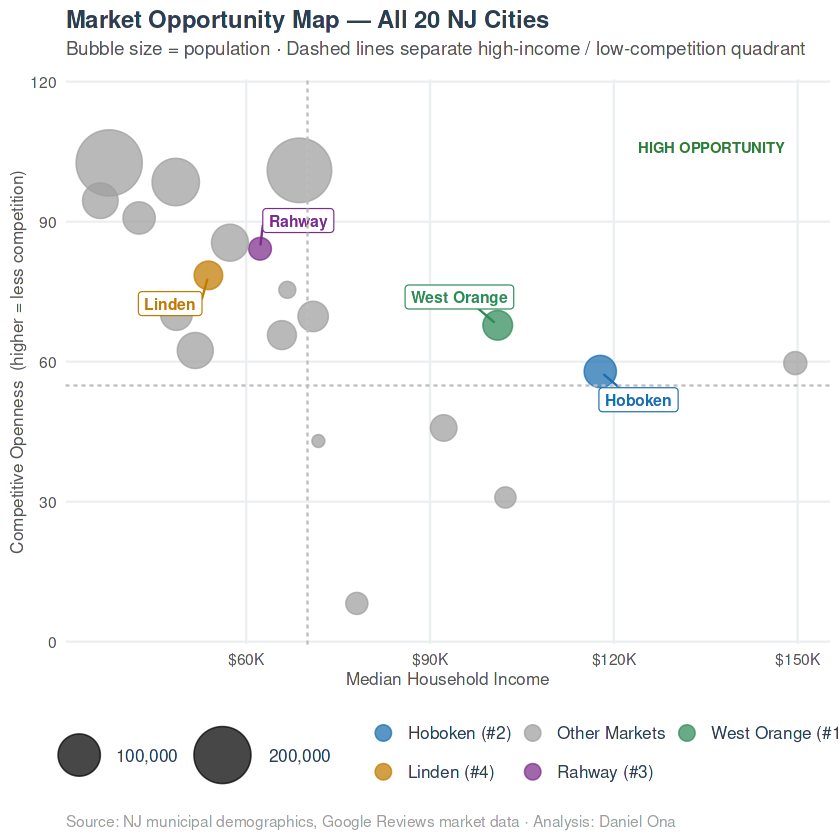

In [36]:
demographics %>%
  mutate(comp_openness = 110 - sat) %>%
  ggplot(aes(x = income, y = comp_openness, size = pop, color = city_group)) +
  geom_point(alpha = 0.72) +
  geom_label_repel(
    # Explicit pre-filter avoids formula-lambda compatibility issues across ggplot2 versions
    data          = demographics %>% mutate(comp_openness = 110 - sat) %>% filter(shortlist),
    aes(label     = city),
    size          = 3.2,
    fontface      = "bold",
    box.padding   = 0.6,
    point.padding = 0.3,
    fill          = "white",
    label.size    = 0.25,
    show.legend   = FALSE
  ) +
  # Quadrant reference lines
  geom_vline(xintercept = 70000, linetype = "dashed", color = "#BDBDBD", linewidth = 0.5) +
  geom_hline(yintercept = 55,    linetype = "dashed", color = "#BDBDBD", linewidth = 0.5) +
  annotate("text", x = 148000, y = 106, label = "HIGH OPPORTUNITY", size = 3,
           color = "#2E7D32", fontface = "bold", hjust = 1) +
  scale_color_manual(values = city_colors) +
  scale_size_continuous(range = c(3, 18), labels = comma, name = "Population") +
  scale_x_continuous(
    labels = label_dollar(scale = 1/1000, suffix = "K"),
    name   = "Median Household Income"
  ) +
  scale_y_continuous(
    name   = "Competitive Openness  (higher = less competition)",
    limits = c(5, 115)
  ) +
  labs(
    title    = "Market Opportunity Map — All 20 NJ Cities",
    subtitle = "Bubble size = population · Dashed lines separate high-income / low-competition quadrant",
    caption  = "Source: NJ municipal demographics, Google Reviews market data · Analysis: Daniel Ona"
  ) +
  guides(
    color = guide_legend(override.aes = list(size = 4), nrow = 2),
    size  = guide_legend(title = "Population", nrow = 1)
  ) +
  theme_dental()


## All 20 Cities Ranked by Opportunity Score


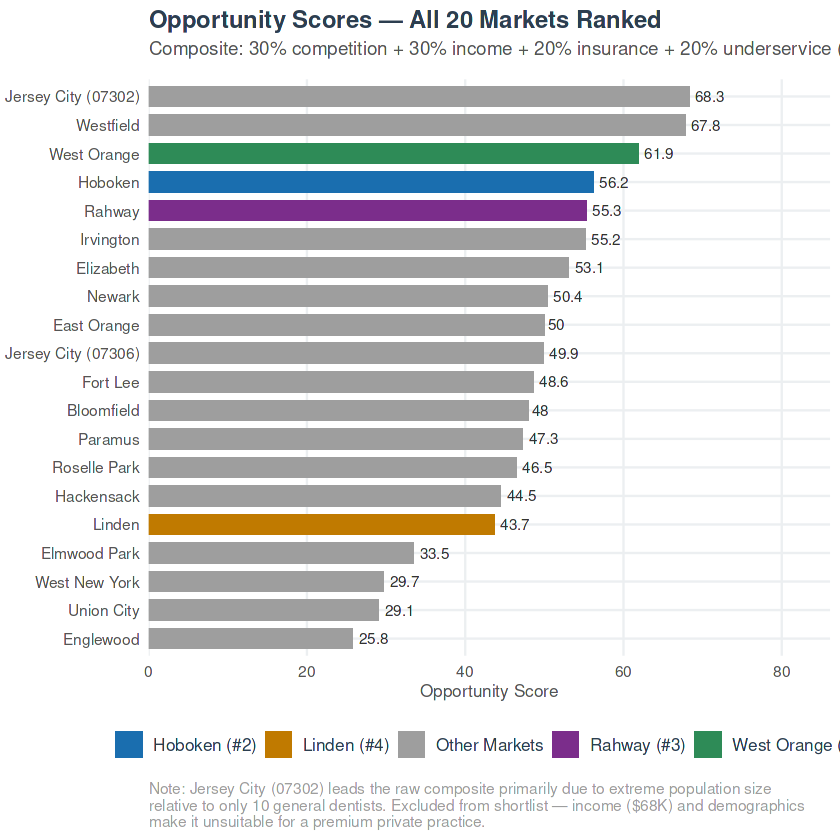

In [37]:
demographics %>%
  mutate(city = fct_reorder(city, opp_score)) %>%
  ggplot(aes(x = opp_score, y = city, fill = city_group)) +
  geom_col(width = 0.72) +
  geom_text(aes(label = opp_score), hjust = -0.2, size = 3.1, color = "#333333") +
  scale_fill_manual(values = city_colors) +
  scale_x_continuous(limits = c(0, 82), expand = expansion(mult = c(0, 0.05))) +
  labs(
    title    = "Opportunity Scores — All 20 Markets Ranked",
    subtitle = "Composite: 30% competition + 30% income + 20% insurance + 20% underservice (0–100 scale)",
    x        = "Opportunity Score",
    y        = NULL,
    caption  = paste0(
      "Note: Jersey City (07302) leads the raw composite primarily due to extreme population size\n",
      "relative to only 10 general dentists. Excluded from shortlist — income ($68K) and demographics\n",
      "make it unsuitable for a premium private practice."
    )
  ) +
  theme_dental()


## People Per General Dentist

Cities with a high people-per-dentist ratio are structurally underserved — there are not enough dentists to meet local demand. A new practice in these markets faces less pressure to steal patients from incumbents; demand is already there.


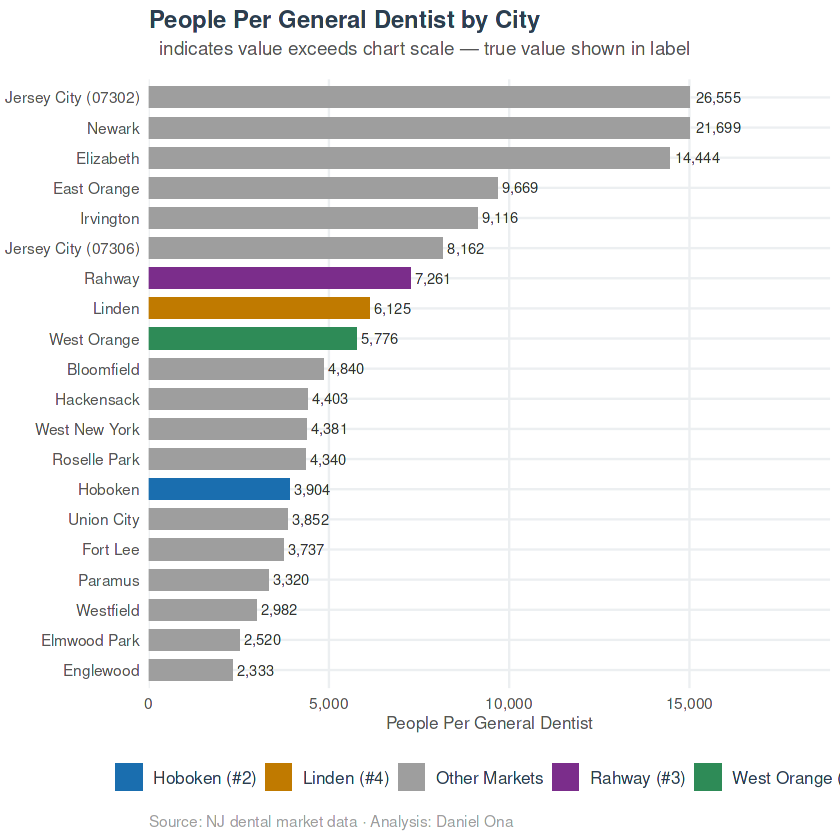

In [38]:
demographics %>%
  mutate(
    city      = fct_reorder(city, ppd),
    ppd_disp  = pmin(ppd, 15000),
    is_capped = ppd > 15000
  ) %>%
  ggplot(aes(x = ppd_disp, y = city, fill = city_group)) +
  geom_col(width = 0.7) +
  geom_text(
    aes(label = if_else(is_capped,
                        paste0(comma(ppd), " ▶"),
                        comma(ppd))),
    hjust = -0.12, size = 3, color = "#333333"
  ) +
  scale_fill_manual(values = city_colors) +
  scale_x_continuous(
    labels = comma,
    limits = c(0, 17500),
    expand = expansion(mult = c(0, 0.08))
  ) +
  labs(
    title    = "People Per General Dentist by City",
    subtitle = "▶ indicates value exceeds chart scale — true value shown in label",
    x        = "People Per General Dentist",
    y        = NULL,
    caption  = "Source: NJ dental market data · Analysis: Daniel Ona"
  ) +
  theme_dental()


## Market Saturation Score

The saturation score measures how many dental practices exist relative to the population. A lower score means fewer practices per capita — less competition, more room to enter.


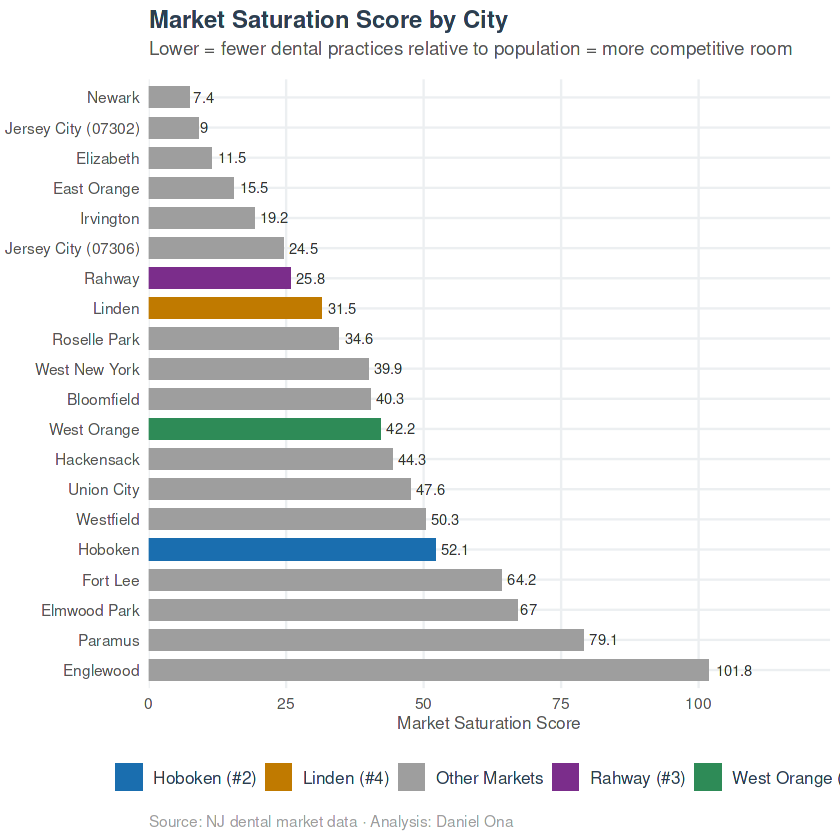

In [39]:
demographics %>%
  mutate(city = fct_reorder(city, desc(sat))) %>%
  ggplot(aes(x = sat, y = city, fill = city_group)) +
  geom_col(width = 0.7) +
  geom_text(aes(label = sat), hjust = -0.2, size = 3, color = "#333333") +
  scale_fill_manual(values = city_colors) +
  scale_x_continuous(limits = c(0, 118), expand = expansion(mult = c(0, 0.05))) +
  labs(
    title    = "Market Saturation Score by City",
    subtitle = "Lower = fewer dental practices relative to population = more competitive room",
    x        = "Market Saturation Score",
    y        = NULL,
    caption  = "Source: NJ dental market data · Analysis: Daniel Ona"
  ) +
  theme_dental()


---

# Top 4 City Comparison

## Dimension-by-Dimension Score Comparison

The following grouped bar chart compares the four shortlisted cities across each individual scoring dimension (all normalized to 0–100), plus the final composite score. It reveals where each city excels and where it is weakest.


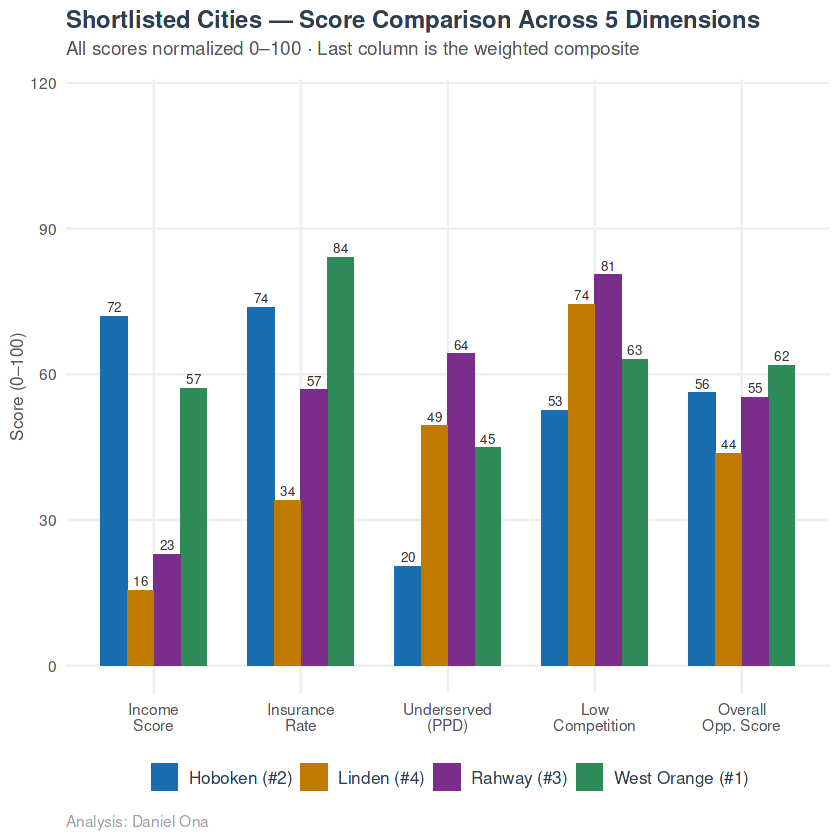

In [40]:
shortlist_long <- demographics %>%
  filter(shortlist) %>%
  select(city, city_group, score_income, score_ins, score_ppd, score_sat, opp_score) %>%
  pivot_longer(
    cols      = c(score_income, score_ins, score_ppd, score_sat, opp_score),
    names_to  = "dimension",
    values_to = "score"
  ) %>%
  mutate(
    dimension = recode(dimension,
      score_income = "Income\nScore",
      score_ins    = "Insurance\nRate",
      score_ppd    = "Underserved\n(PPD)",
      score_sat    = "Low\nCompetition",
      opp_score    = "Overall\nOpp. Score"
    ),
    dimension = fct_relevel(dimension,
      "Income\nScore", "Insurance\nRate", "Underserved\n(PPD)",
      "Low\nCompetition", "Overall\nOpp. Score"
    )
  )

shortlist_long %>%
  ggplot(aes(x = dimension, y = score, fill = city_group)) +
  geom_col(position = "dodge", width = 0.72) +
  geom_text(
    aes(label = round(score, 0)),
    position = position_dodge(width = 0.72),
    vjust = -0.4, size = 2.7, color = "#333333"
  ) +
  scale_fill_manual(values = city_colors) +
  scale_y_continuous(limits = c(0, 115)) +
  labs(
    title    = "Shortlisted Cities — Score Comparison Across 5 Dimensions",
    subtitle = "All scores normalized 0–100 · Last column is the weighted composite",
    x        = NULL,
    y        = "Score (0–100)",
    caption  = "Analysis: Daniel Ona"
  ) +
  theme_dental()


## Head-to-Head Metrics Table


In [41]:
demographics %>%
  filter(shortlist) %>%
  arrange(desc(opp_score)) %>%
  mutate(
    pop    = comma(pop),
    income = dollar(income),
    ins    = paste0(ins, "%"),
    edu    = paste0(edu, "%"),
    ppd    = comma(ppd)
  ) %>%
  select(city, county, pop, income, ins, edu, practices, gen_d, ppd, sat, rating, opp_score) %>%
  rename(
    City = city, County = county, Population = pop, `Median Income` = income,
    `Ins. Rate` = ins, `College Ed.` = edu, Practices = practices,
    `Gen. Dentists` = gen_d, `People/Dentist` = ppd,
    `Sat. Score` = sat, `Avg Rating` = rating, `Opp. Score` = opp_score
  ) %>%
  kable(align = c("l","l","r","r","r","r","r","r","r","r","r","r")) %>%
  kable_styling(bootstrap_options = c("striped","hover"), full_width = TRUE) %>%
  row_spec(1, bold = TRUE, color = "white", background = "#2E7D32") %>%
  row_spec(2, bold = TRUE, color = "white", background = "#1565C0") %>%
  row_spec(3, bold = TRUE, color = "white", background = "#6A1B9A") %>%
  row_spec(4, bold = TRUE, color = "white", background = "#C05000")


<table class="table table-striped table-hover" style="margin-left: auto; margin-right: auto;">
 <thead>
  <tr>
   <th style="text-align:left;"> City </th>
   <th style="text-align:left;"> County </th>
   <th style="text-align:right;"> Population </th>
   <th style="text-align:right;"> Median Income </th>
   <th style="text-align:right;"> Ins. Rate </th>
   <th style="text-align:right;"> College Ed. </th>
   <th style="text-align:right;"> Practices </th>
   <th style="text-align:right;"> Gen. Dentists </th>
   <th style="text-align:right;"> People/Dentist </th>
   <th style="text-align:right;"> Sat. Score </th>
   <th style="text-align:right;"> Avg Rating </th>
   <th style="text-align:right;"> Opp. Score </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;font-weight: bold;color: white !important;background-color: rgba(46, 125, 50, 255) !important;"> West Orange </td>
   <td style="text-align:left;font-weight: bold;color: white !important;background-color: rgba(46, 125

---

# 3-Year Cost Projections

Operating costs were projected over three years for the four shortlisted cities. All salary figures are benchmarked to NJ Bureau of Labor Statistics and Salary.com 2025 market data, with a location multiplier applied to reflect each city's cost of living tier.

**Dentist figures represent owner draw**, not a full employee salary — they ramp from a reduced startup draw in Year 1 toward market rate (~$200K–$235K) by Year 3.

## 3-Year Cost Trajectory


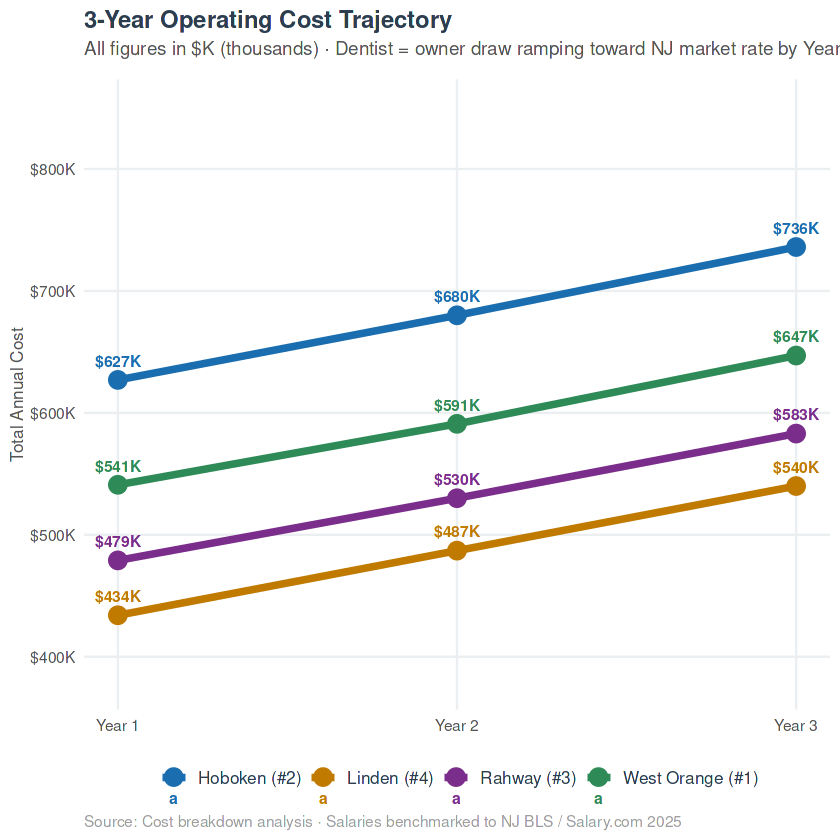

In [42]:
cost_totals <- costs %>%
  group_by(city, year) %>%
  summarise(total = sum(amount), .groups = "drop") %>%
  mutate(
    city_group = case_when(
      city == "West Orange" ~ "West Orange (#1)",
      city == "Hoboken"     ~ "Hoboken (#2)",
      city == "Rahway"      ~ "Rahway (#3)",
      city == "Linden"      ~ "Linden (#4)"
    )
  )

cost_totals %>%
  ggplot(aes(x = year, y = total, color = city_group, group = city)) +
  geom_line(linewidth = 1.6) +
  geom_point(size = 4.5) +
  geom_text(
    aes(label = paste0("$", comma(total), "K")),
    vjust = -1.1, size = 3.2, fontface = "bold"
  ) +
  scale_color_manual(values = city_colors) +
  scale_x_continuous(breaks = 1:3, labels = paste0("Year ", 1:3)) +
  scale_y_continuous(
    labels = label_dollar(suffix = "K"),
    limits = c(380, 850)   # extended to give room for Hoboken Y3 ($736K) label
  ) +
  labs(
    title    = "3-Year Operating Cost Trajectory",
    subtitle = "All figures in $K (thousands) · Dentist = owner draw ramping toward NJ market rate by Year 3",
    x        = NULL,
    y        = "Total Annual Cost",
    caption  = "Source: Cost breakdown analysis · Salaries benchmarked to NJ BLS / Salary.com 2025"
  ) +
  theme_dental()


## Year 1 Cost Breakdown by Category


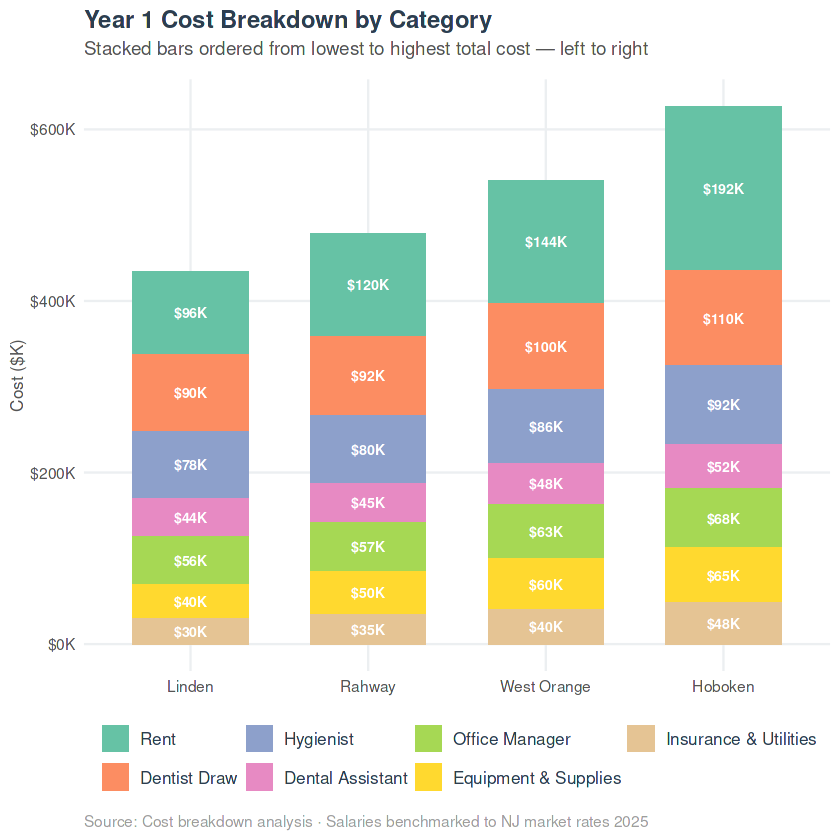

In [43]:
cat_order <- c(
  "Rent", "Dentist Draw", "Hygienist", "Dental Assistant",
  "Office Manager", "Equipment & Supplies", "Insurance & Utilities"
)

city_order <- c("Linden", "Rahway", "West Orange", "Hoboken")

costs %>%
  filter(year == 1) %>%
  mutate(
    category = fct_relevel(category, cat_order),
    city     = fct_relevel(city, city_order)
  ) %>%
  ggplot(aes(x = city, y = amount, fill = category)) +
  geom_col(width = 0.65) +
  geom_text(
    aes(label = paste0("$", amount, "K")),
    position  = position_stack(vjust = 0.5),
    size      = 2.9,
    color     = "white",
    fontface  = "bold"
  ) +
  scale_fill_brewer(palette = "Set2") +
  scale_y_continuous(labels = label_dollar(suffix = "K")) +
  labs(
    title    = "Year 1 Cost Breakdown by Category",
    subtitle = "Stacked bars ordered from lowest to highest total cost — left to right",
    x        = NULL,
    y        = "Cost ($K)",
    caption  = "Source: Cost breakdown analysis · Salaries benchmarked to NJ market rates 2025"
  ) +
  theme_dental()


---

# Salary Benchmarks

All budgeted salaries were validated against NJ market data from BLS 2025, Salary.com, and ZipRecruiter NJ. The chart below shows Year 1 budgeted salaries relative to the NJ market median (red dashed line) for each role across all four shortlisted cities.

Note that the **dentist figure is a startup owner draw** — well below the NJ market employment salary for a reason. A practice owner in Year 1 is reinvesting in the business; the draw increases toward market rate by Year 3.


In [44]:
budgeted <- tribble(
  ~role,                      ~city,          ~y1,
  "General Dentist\n(draw)",  "West Orange",  100000,
  "General Dentist\n(draw)",  "Hoboken",      110000,
  "General Dentist\n(draw)",  "Rahway",       92000,
  "General Dentist\n(draw)",  "Linden",       90000,
  "Dental\nHygienist",        "West Orange",  86000,
  "Dental\nHygienist",        "Hoboken",      92000,
  "Dental\nHygienist",        "Rahway",       80000,
  "Dental\nHygienist",        "Linden",       78000,
  "Dental\nAssistant",        "West Orange",  48000,
  "Dental\nAssistant",        "Hoboken",      52000,
  "Dental\nAssistant",        "Rahway",       45000,
  "Dental\nAssistant",        "Linden",       44000,
  "Office\nManager",          "West Orange",  63000,
  "Office\nManager",          "Hoboken",      68000,
  "Office\nManager",          "Rahway",       57000,
  "Office\nManager",          "Linden",       56000
) %>%
  mutate(
    city_group = case_when(
      city == "West Orange" ~ "West Orange (#1)",
      city == "Hoboken"     ~ "Hoboken (#2)",
      city == "Rahway"      ~ "Rahway (#3)",
      city == "Linden"      ~ "Linden (#4)"
    ),
    city = fct_relevel(city, "Linden","Rahway","West Orange","Hoboken")
  )


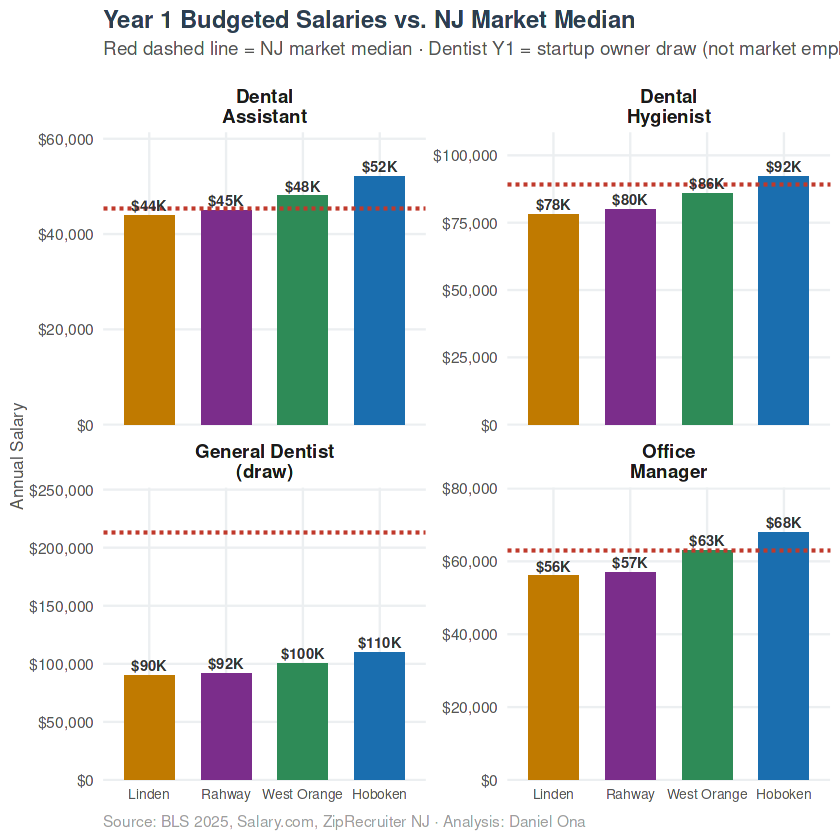

In [45]:
budgeted %>%
  ggplot(aes(x = city, y = y1, fill = city_group)) +
  geom_col(width = 0.65) +
  geom_hline(
    data     = salaries,
    aes(yintercept = nj_median),
    linetype = "dashed", color = "#C0392B", linewidth = 0.9
  ) +
  geom_text(
    # paste0 avoids scales::dollar() version-sensitivity with scale/suffix args
    aes(label = paste0("$", y1 / 1000, "K")),
    vjust = -0.4, size = 3, color = "#333333", fontface = "bold"
  ) +
  scale_fill_manual(values = city_colors) +
  scale_y_continuous(labels = label_dollar(), expand = expansion(mult = c(0, 0.18))) +
  facet_wrap(~role, scales = "free_y", nrow = 2) +
  labs(
    title    = "Year 1 Budgeted Salaries vs. NJ Market Median",
    subtitle = "Red dashed line = NJ market median · Dentist Y1 = startup owner draw (not market employment rate)",
    x        = NULL,
    y        = "Annual Salary",
    caption  = "Source: BLS 2025, Salary.com, ZipRecruiter NJ · Analysis: Daniel Ona"
  ) +
  theme_dental() +
  theme(
    legend.position = "none",
    axis.text.x     = element_text(size = 8)
  )


In [46]:
salaries %>%
  mutate(across(c(nj_low, nj_median, nj_high), dollar)) %>%
  rename(
    Role = role,
    `NJ Market Low` = nj_low,
    `NJ Median`     = nj_median,
    `NJ Market High` = nj_high
  ) %>%
  mutate(Role = gsub("\n", " ", Role)) %>%
  kable(align = c("l","r","r","r")) %>%
  kable_styling(bootstrap_options = c("striped","hover"), full_width = FALSE) %>%
  column_spec(3, bold = TRUE, color = "#1565C0") %>%
  # footnote() is the current kableExtra API (add_footnote is deprecated)
  footnote(
    general       = c("Source: BLS 2025, Salary.com, ZipRecruiter NJ",
                      "Dentist figure = NJ employed dentist rate; owner draw is lower in startup years"),
    general_title = ""
  )


<table class="table table-striped table-hover" style="width: auto !important; margin-left: auto; margin-right: auto;border-bottom: 0;">
 <thead>
  <tr>
   <th style="text-align:left;"> Role </th>
   <th style="text-align:right;"> NJ Market Low </th>
   <th style="text-align:right;"> NJ Median </th>
   <th style="text-align:right;"> NJ Market High </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;"> General Dentist (draw) </td>
   <td style="text-align:right;"> $196,229 </td>
   <td style="text-align:right;font-weight: bold;color: rgba(21, 101, 192, 255) !important;"> $213,338 </td>
   <td style="text-align:right;"> $293,810 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> Dental Hygienist </td>
   <td style="text-align:right;"> $82,208 </td>
   <td style="text-align:right;font-weight: bold;color: rgba(21, 101, 192, 255) !important;"> $89,303 </td>
   <td style="text-align:right;"> $98,490 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> Dental Assistant </t

---

# Final Recommendations

## 🥇 West Orange, NJ — Primary Recommendation

West Orange is the most compelling market in this dataset for a new **premium private dental practice**. It holds an unusual combination: a median household income of **$101,058** paired with only **8 general dentists** serving a population of 46,207 — yielding 5,776 people per dentist, the highest ratio among all high-income markets analyzed.

The existing practices rate an average of **4.8 stars**, indicating that quality care is valued and rewarded here. A new practice positioned around cosmetic dentistry, implants, and Invisalign would enter a market with proven demand and a real supply gap.

**Year 1 budget: $541K · Year 3 budget: $647K**

## 🥈 Hoboken, NJ — Strong Alternative

Hoboken offers the **highest median income** in the dataset ($117,795) and a young professional demographic that represents long-term, high-lifetime-value patients. Market intelligence confirms a documented gap in **implant and orthodontic services** — existing practices focus on general and family dentistry, leaving specialty demand unmet.

The trade-offs are meaningful: 19 practices already operate in the market, and rent at **$16,000/month** is the highest of the four cities analyzed. Success here requires clear differentiation by service line, which the data supports as achievable.

**Year 1 budget: $627K · Year 3 budget: $736K**

## Linden & Rahway — Budget-Conscious Alternatives

Both cities offer lower entry costs and measurable market gaps. **Rahway** has the lowest saturation score in Union County (25.8) and almost no specialty care — a new practice would essentially have the field to itself for implants and cosmetic work. **Linden** offers the largest patient pool at 42,876 residents, though income levels limit premium service uptake.

These markets are better suited to a general/family practice model with selective cosmetic services, rather than a premium specialty-focused positioning.

---

# Acknowledgments

This project would not exist without two people who inspire me every day.

To my **wife**, whose years of experience as a dental **office manager** gave me an insider's view of how dental practices operate, what makes them succeed, and what gaps are routinely left unfilled in the market — thank you for answering every question I had, for explaining insurance billing over dinner more times than either of us can count, and for being the operational mind behind this analysis even if you did not write a single line of R.

To my **sister**, a dedicated dental **hygienist** who has always led with her care for patients — thank you for the clinical perspective, for the reminders that behind every data point is a real person who needs quality care, and for showing me that this industry is driven by people who genuinely want to make a difference.

This was my first data analysis project from end to end: raw data → validation → scoring → visualization → reporting in R. I hope it is the first of many.

---

# Session Information


In [47]:
sessionInfo()


R version 4.4.0 (2024-04-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.4 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.20.so;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggrepel_0.9.6    kableExtra_1.4.0 knitr_1.49       scales_1.3.0    
 [5] lubridate_1.9.4  forcats_1.0.0    stringr_1.5.1    dplyr_1.1.4     
 [9] purrr_1.0.2      readr_2.1.5